In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

demo = pd.read_sas("data/DEMO_G.xpt")
older = demo[demo["RIDAGEYR"] >= 50]
print(older.shape)

(2704, 48)


In [2]:
diet = pd.read_sas("data/DR1TOT_G.xpt")
print(diet.shape)
print(diet.columns.tolist())

(9338, 166)
['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MNRSP', 'DR1HELPD', 'DBQ095Z', 'DBD100', 'DRQSPREP', 'DRQSDIET', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT5', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DR1TNUMF', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1TVARA', 'DR1TACAR', 'DR1TBCAR', 'DR1TCRYP', 'DR1TLYCO', 'DR1TLZ', 'DR1TVB1', 'DR1TVB2', 'DR1TNIAC', 'DR1TVB6', 'DR1TFOLA', 'DR1TFA', 'DR1TFF', 'DR1TFDFE', 'DR1TCHL', 'DR1TVB12', 'DR1TB12A', 'DR1TVC', 'DR1TVD', 'DR1TVK', 'DR1TCALC', 'DR1TPHOS', 'DR1TMAGN', 'DR1TIRON', 'DR1TZINC', 'DR1TCOPP', 'DR1TSODI', 'DR1TPOTA', 'DR1TSELE', 'DR1TCAFF', 'DR1TTHEO', 'DR1TALCO', 'DR1TMOIS', 'DR1TS040', 'DR1TS060', 'DR1TS080', 'DR1TS100', 'DR1TS120', 'DR1TS140', 'DR1TS160', 'DR1TS180', 'DR1TM161', 'DR1TM181', '

In [3]:
print("Recall status:")
print(diet["DR1DRSTZ"].value_counts(dropna=False))

print("\nSpecial diet:")
print(diet["DRQSDIET"].value_counts(dropna=False))

print("\nEnergy:")
print(diet["DR1TKCAL"].describe())

Recall status:
DR1DRSTZ
1.0    8389
5.0     720
4.0     130
2.0      99
Name: count, dtype: int64

Special diet:
DRQSDIET
2.0    7747
1.0     822
NaN     720
9.0      49
Name: count, dtype: int64

Energy:
count    8.389000e+03
mean     1.993984e+03
std      9.511961e+02
min      5.397605e-79
25%      1.337000e+03
50%      1.829000e+03
75%      2.443000e+03
max      1.368700e+04
Name: DR1TKCAL, dtype: float64


In [4]:
df = older.merge(diet, on="SEQN", how="inner")
print("After merge:", df.shape)

df = df[df["DR1DRSTZ"] == 1]
print("After reliable recall:", df.shape)

df["special_diet"] = df["DRQSDIET"].map({1: 1, 2: 0})
print(df["special_diet"].value_counts(dropna=False))

After merge: (2566, 213)
After reliable recall: (2306, 213)
special_diet
0.0    1912
1.0     389
NaN       5
Name: count, dtype: int64


In [5]:
implausible = (
    ((df["RIAGENDR"] == 2) & ((df["DR1TKCAL"] < 500) | (df["DR1TKCAL"] > 3500))) |
    ((df["RIAGENDR"] == 1) & ((df["DR1TKCAL"] < 800) | (df["DR1TKCAL"] > 4000)))
)
print("Implausible energy reports:", implausible.sum())

df = df[~implausible]
print("After energy exclusion:", df.shape)
print(df["DR1TKCAL"].describe().round(2))

Implausible energy reports: 100
After energy exclusion: (2206, 214)
count    2206.00
mean     1870.76
std       706.17
min       502.00
25%      1338.00
50%      1767.50
75%      2307.00
max      3978.00
Name: DR1TKCAL, dtype: float64


In [6]:
components = {
    "DR1TFIBE": "fibre",
    "DR1TPOTA": "potassium",
    "DR1TMAGN": "magnesium",
    "DR1TCALC": "calcium",
    "DR1TVC": "vitamin_c",
    "DR1TSODI": "sodium",
    "DR1TSFAT": "sat_fat",
    "DR1TSUGR": "sugar",
}

for nhanes_name, readable_name in components.items():
    df[readable_name + "_dens"] = df[nhanes_name] / df["DR1TKCAL"] * 1000

print(df[[c + "_dens" for c in components.values()]].describe())

         fibre_dens  potassium_dens  magnesium_dens  calcium_dens  \
count  2.206000e+03     2206.000000     2206.000000   2206.000000   
mean   9.285844e+00     1419.413235      155.344678    460.279708   
std    4.882423e+00      488.926572       54.169554    225.183245   
min    3.109220e-79      361.664918       42.437432     48.706240   
25%    5.962779e+00     1092.023770      117.301190    297.505957   
50%    8.156526e+00     1347.019598      146.060232    425.798323   
75%    1.183157e+01     1694.476157      184.548036    580.815656   
max    4.531524e+01     8395.359019      647.985989   2258.579409   

       vitamin_c_dens  sodium_dens  sat_fat_dens   sugar_dens  
count    2.206000e+03  2206.000000  2.206000e+03  2206.000000  
mean     4.745258e+01  1719.657866  1.142898e+01    54.060003  
std      5.183360e+01   563.670670  4.340554e+00    24.966932  
min      1.933240e-79    61.059908  3.109220e-79     1.173333  
25%      1.359991e+01  1349.052418  8.353520e+00    36.181

In [7]:
#checking on minimums of 0.00 on fibre and vitamin C. Someone reported eating no fibre in a day.
print("Zero fibre:", (df["fibre_dens"] < 0.5).sum())
print("Zero vitamin C:", (df["vitamin_c_dens"] < 0.5).sum())
print(df.loc[df["fibre_dens"] < 0.5, ["DR1TKCAL", "DR1TNUMF", "DR1TFIBE", "DR1TPROT"]])

Zero fibre: 2
Zero vitamin C: 37
      DR1TKCAL  DR1TNUMF      DR1TFIBE  DR1TPROT
918     1479.0      13.0  7.000000e-01     32.16
1667    1736.0       1.0  5.397605e-79      1.48


In [8]:
positive = ["fibre", "potassium", "magnesium", "calcium", "vitamin_c"]
negative = ["sodium", "sat_fat", "sugar"]

for c in positive:
    df[c + "_q"] = pd.qcut(df[c + "_dens"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

for c in negative:
    df[c + "_q"] = pd.qcut(df[c + "_dens"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

score_cols = [c + "_q" for c in positive + negative]
df["diet_score"] = df[score_cols].sum(axis=1)

print(df["diet_score"].describe().round(2))

count    2206.00
mean       24.00
std         5.56
min        10.00
25%        20.00
50%        24.00
75%        28.00
max        37.00
Name: diet_score, dtype: float64


In [9]:
dens_cols = [c + "_dens" for c in positive + negative]
print(df[dens_cols].corr().round(2))

                fibre_dens  potassium_dens  magnesium_dens  calcium_dens  \
fibre_dens            1.00            0.57            0.70          0.18   
potassium_dens        0.57            1.00            0.71          0.35   
magnesium_dens        0.70            0.71            1.00          0.37   
calcium_dens          0.18            0.35            0.37          1.00   
vitamin_c_dens        0.31            0.50            0.34          0.17   
sodium_dens           0.08            0.20            0.11          0.09   
sat_fat_dens         -0.30           -0.27           -0.33          0.18   
sugar_dens           -0.05            0.06           -0.07          0.11   

                vitamin_c_dens  sodium_dens  sat_fat_dens  sugar_dens  
fibre_dens                0.31         0.08         -0.30       -0.05  
potassium_dens            0.50         0.20         -0.27        0.06  
magnesium_dens            0.34         0.11         -0.33       -0.07  
calcium_dens              0

In [10]:
bmx = pd.read_sas("data/BMX_G.xpt")
bpx = pd.read_sas("data/BPX_G.xpt")
ghb = pd.read_sas("data/GHB_G.xpt")
hdl = pd.read_sas("data/HDL_G.xpt")
trigly = pd.read_sas("data/TRIGLY_G.xpt")
glu = pd.read_sas("data/GLU_G.xpt")

for name, table in [("bmx", bmx), ("bpx", bpx), ("ghb", ghb),
                    ("hdl", hdl), ("trigly", trigly), ("glu", glu)]:
    print(name, table.shape)

bmx (9338, 26)
bpx (9338, 27)
ghb (6549, 2)
hdl (7821, 3)
trigly (3239, 6)
glu (3239, 8)


In [11]:
lab_files = [
    (bmx[["SEQN", "BMXBMI", "BMXWAIST"]], "bmx"),
    (bpx[["SEQN", "BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4",
          "BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]], "bpx"),
    (ghb[["SEQN", "LBXGH"]], "ghb"),
    (hdl[["SEQN", "LBDHDD"]], "hdl"),
    (trigly[["SEQN", "LBXTR"]], "trigly"),
    (glu[["SEQN", "LBXGLU", "PHAFSTHR"]], "glu"),
]

for table, name in lab_files:
    df = df.merge(table, on="SEQN", how="left")
    print(f"after {name}: {df.shape}")

after bmx: (2206, 233)
after bpx: (2206, 241)
after ghb: (2206, 242)
after hdl: (2206, 243)
after trigly: (2206, 244)
after glu: (2206, 246)


In [12]:
df["sbp"] = df[["BPXSY2", "BPXSY3"]].mean(axis=1)
df["dbp_raw"] = df[["BPXDI2", "BPXDI3"]].mean(axis=1)   # renamed from "dbp"

print(df[["sbp", "dbp_raw"]].describe().round(2))
print("Missing SBP:", df["sbp"].isna().sum())
print("Missing DBP:", df["dbp_raw"].isna().sum())
print("Zero DBP:", (df["dbp_raw"] == 0).sum())

           sbp  dbp_raw
count  2144.00  2144.00
mean    130.81    69.91
std      19.48    14.57
min      81.00     0.00
25%     118.00    63.00
50%     129.00    71.00
75%     141.00    79.00
max     233.00   115.00
Missing SBP: 62
Missing DBP: 62
Zero DBP: 0


In [13]:
print("Zero in BPXDI2:", (df["BPXDI2"] == 0).sum())
print("Zero in BPXDI3:", (df["BPXDI3"] == 0).sum())
print("Low dbp (<40):", (df["dbp_raw"] < 40).sum())

Zero in BPXDI2: 0
Zero in BPXDI3: 0
Low dbp (<40): 59


In [14]:
print(df.loc[df["dbp_raw"] < 40, ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4", "dbp_raw"]].head(20))
print(df["dbp_raw"].sort_values().head(10).tolist())

           BPXDI1        BPXDI2        BPXDI3        BPXDI4       dbp_raw
0             NaN  3.800000e+01  4.000000e+01  3.600000e+01  3.900000e+01
26   4.800000e+01  4.200000e+01  5.397605e-79           NaN  2.100000e+01
42   3.200000e+01  3.600000e+01  4.000000e+01           NaN  3.800000e+01
106  3.800000e+01  5.397605e-79  4.600000e+01           NaN  2.300000e+01
149  4.200000e+01  5.397605e-79  5.397605e-79           NaN  5.397605e-79
182  4.600000e+01  3.200000e+01  5.397605e-79           NaN  1.600000e+01
202  5.200000e+01  5.397605e-79  5.397605e-79           NaN  5.397605e-79
250  5.000000e+01  2.800000e+01  4.000000e+01           NaN  3.400000e+01
359  6.000000e+01  5.600000e+01  5.397605e-79           NaN  2.800000e+01
364  3.800000e+01  3.600000e+01  3.800000e+01           NaN  3.700000e+01
396  5.397605e-79  5.397605e-79  3.800000e+01           NaN  1.900000e+01
420  7.800000e+01  5.397605e-79  7.200000e+01           NaN  3.600000e+01
436           NaN  5.397605e-79  5.397

In [15]:
bp_cols = ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]
df[bp_cols] = df[bp_cols].mask(df[bp_cols] < 1)

df["dbp"] = df[["BPXDI2", "BPXDI3"]].mean(axis=1)

print(df[["sbp", "dbp"]].describe().round(2))
print("Missing DBP now:", df["dbp"].isna().sum())
print("Low dbp (<40):", (df["dbp"] < 40).sum())

           sbp      dbp
count  2144.00  2127.00
mean    130.81    70.74
std      19.48    12.50
min      81.00    21.00
25%     118.00    64.00
50%     129.00    71.00
75%     141.00    79.00
max     233.00   115.00
Missing DBP now: 79
Low dbp (<40): 24


In [16]:
bpq = pd.read_sas("data/BPQ_G.xpt")
diq = pd.read_sas("data/DIQ_G.xpt")

print("BPQ:", bpq.columns.tolist())
print("DIQ:", diq.columns.tolist())

BPQ: ['SEQN', 'BPQ020', 'BPQ030', 'BPD035', 'BPQ040A', 'BPQ050A', 'BPQ057', 'BPQ056', 'BPD058', 'BPQ059', 'BPQ080', 'BPQ060', 'BPQ070', 'BPQ090D', 'BPQ100D']
DIQ: ['SEQN', 'DIQ010', 'DID040', 'DIQ160', 'DIQ170', 'DIQ172', 'DIQ175A', 'DIQ175B', 'DIQ175C', 'DIQ175D', 'DIQ175E', 'DIQ175F', 'DIQ175G', 'DIQ175H', 'DIQ175I', 'DIQ175J', 'DIQ175K', 'DIQ175L', 'DIQ175M', 'DIQ175N', 'DIQ175O', 'DIQ175P', 'DIQ175Q', 'DIQ175R', 'DIQ175S', 'DIQ175T', 'DIQ175U', 'DIQ175V', 'DIQ175W', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'DIQ230', 'DIQ240', 'DID250', 'DID260', 'DIQ260U', 'DIQ275', 'DIQ280', 'DIQ291', 'DIQ300S', 'DIQ300D', 'DID310S', 'DID310D', 'DID320', 'DID330', 'DID341', 'DID350', 'DIQ350U', 'DIQ360', 'DIQ080']


In [17]:
med = bpq[["SEQN", "BPQ050A", "BPQ100D"]].merge(
    diq[["SEQN", "DIQ010", "DIQ050", "DIQ070"]], on="SEQN", how="outer")

print("med rows:", len(med))
print("df rows before merge:", len(df))

df = df.merge(med, on="SEQN", how="left")
print("df rows after merge:", len(df))

for c in ["BPQ050A", "BPQ100D", "DIQ010", "DIQ050", "DIQ070"]:
    print("\n---", c)
    print(df[c].value_counts(dropna=False).sort_index())

med rows: 9364
df rows before merge: 2206
df rows after merge: 2206

--- BPQ050A
BPQ050A
1.0    1073
2.0      98
9.0       1
NaN    1034
Name: count, dtype: int64

--- BPQ100D
BPQ100D
1.0     803
2.0     168
9.0       2
NaN    1233
Name: count, dtype: int64

--- DIQ010
DIQ010
1.0     483
2.0    1645
3.0      76
9.0       2
Name: count, dtype: int64

--- DIQ050
DIQ050
1.0     146
2.0    2060
Name: count, dtype: int64

--- DIQ070
DIQ070
1.0     390
2.0     299
9.0       1
NaN    1516
Name: count, dtype: int64


In [18]:
df["bp_med"]   = (df["BPQ050A"] == 1).astype(int)
df["chol_med"] = (df["BPQ100D"] == 1).astype(int)
df["dm_dx"]    = (df["DIQ010"] == 1).astype(int)
df["dm_med"]   = ((df["DIQ050"] == 1) | (df["DIQ070"] == 1)).astype(int)

for c in ["bp_med", "chol_med", "dm_dx", "dm_med"]:
    print(c, df[c].sum(), f"{df[c].mean()*100:.1f}%")

print("\ndm_med by dm_dx:")
print(pd.crosstab(df["dm_dx"], df["dm_med"]))

bp_med 1073 48.6%
chol_med 803 36.4%
dm_dx 483 21.9%
dm_med 453 20.5%

dm_med by dm_dx:
dm_med     0    1
dm_dx            
0       1693   30
1         60  423


In [19]:
print(df.loc[df["dm_med"] == 1, "DIQ010"].value_counts(dropna=False))

DIQ010
1.0    423
3.0     18
2.0     12
Name: count, dtype: int64


In [20]:
print(df["LBXGLU"].notna().sum())
print(df["LBXTR"].notna().sum())
print((df["LBXGLU"].notna() & df["LBXTR"].notna()).sum())

1035
1016
1015


In [21]:
df["waist_high"] = (
    ((df["RIAGENDR"] == 1) & (df["BMXWAIST"] >= 102)) |
    ((df["RIAGENDR"] == 2) & (df["BMXWAIST"] >= 88))
).astype(int)

print(df["waist_high"].sum(), round(df["waist_high"].mean(), 3))
print(df["BMXWAIST"].isna().sum())

1320 0.598
113


In [22]:
print(df.loc[df["BMXWAIST"].isna(), ["BMXBMI"]].isna().sum())

BMXBMI    23
dtype: int64


In [23]:
fasting = df["LBXGLU"].notna() & df["LBXTR"].notna()
assert fasting.index.equals(df.index), "fasting mask no longer aligns with df"
print("fasting subsample:", int(fasting.sum()))
print("waist missing in fasting subsample:", int(df.loc[fasting, "BMXWAIST"].isna().sum()))

fasting subsample: 1015
waist missing in fasting subsample: 39


In [24]:
df["gluc_high"] = (
    (df["LBXGLU"] >= 100) | (df["dm_dx"] == 1) | (df["dm_med"] == 1)
).astype(int)

print(df["gluc_high"].sum(), f"{df['gluc_high'].mean()*100:.1f}%")
print(pd.crosstab(df["LBXGLU"] >= 100, df["dm_dx"]))

969 43.9%
dm_dx      0    1
LBXGLU           
False   1256  268
True     467  215


In [25]:
print(df.loc[fasting, "gluc_high"].sum(), f"{df.loc[fasting, 'gluc_high'].mean()*100:.1f}%")

688 67.8%


In [26]:
df["hdl_low"] = (
    ((df["RIAGENDR"] == 1) & (df["LBDHDD"] < 40)) |
    ((df["RIAGENDR"] == 2) & (df["LBDHDD"] < 50)) |
    (df["chol_med"] == 1)
).astype(int)

df["trig_high"] = (
    (df["LBXTR"] >= 150) | (df["chol_med"] == 1)
).astype(int)

for c in ["hdl_low", "trig_high"]:
    print(c, df[c].sum(), f"{df[c].mean()*100:.1f}%",
          "| fasting:", df.loc[fasting, c].sum(),
          f"{df.loc[fasting, c].mean()*100:.1f}%")

print("LBDHDD missing:", df["LBDHDD"].isna().sum())

hdl_low 1147 52.0% | fasting: 528 52.0%
trig_high 955 43.3% | fasting: 532 52.4%
LBDHDD missing: 158


In [27]:
print(df.loc[fasting, "LBDHDD"].isna().sum())

0


In [28]:
print(pd.crosstab(df.loc[fasting, "chol_med"],
                  df.loc[fasting, ["hdl_low", "trig_high"]].sum(axis=1)))

col_0       0    1    2
chol_med               
0         407  156   72
1           0    0  380


In [29]:
df["hdl_low_meas"] = (
    ((df["RIAGENDR"] == 1) & (df["LBDHDD"] < 40)) |
    ((df["RIAGENDR"] == 2) & (df["LBDHDD"] < 50))
).astype(int)

df["trig_high_meas"] = (df["LBXTR"] >= 150).astype(int)

for c in ["hdl_low_meas", "trig_high_meas"]:
    print(c, df.loc[fasting, c].sum(), f"{df.loc[fasting, c].mean()*100:.1f}%")

hdl_low_meas 244 24.0%
trig_high_meas 262 25.8%


In [30]:
df["bp_high"] = (
    (df["sbp"] >= 130) | (df["dbp"] >= 85) | (df["bp_med"] == 1)
).astype(int)

print(df["bp_high"].sum(), f"{df['bp_high'].mean()*100:.1f}%",
      "| fasting:", df.loc[fasting, "bp_high"].sum(),
      f"{df.loc[fasting, 'bp_high'].mean()*100:.1f}%")

print("sbp missing:", df["sbp"].isna().sum(), "| fasting:", df.loc[fasting, "sbp"].isna().sum())

1554 70.4% | fasting: 703 69.3%
sbp missing: 62 | fasting: 36


In [31]:
mets_cols = ["waist_high", "bp_high", "gluc_high", "trig_high", "hdl_low"]

df["mets_count"] = df[mets_cols].sum(axis=1)
df["mets"] = (df["mets_count"] >= 3).astype(int)

print(df.loc[fasting, "mets_count"].value_counts().sort_index())
print()
print("MetS:", df.loc[fasting, "mets"].sum(),
      f"{df.loc[fasting, 'mets'].mean()*100:.1f}%")

mets_count
0     59
1    122
2    187
3    223
4    214
5    210
Name: count, dtype: int64

MetS: 647 63.7%


In [32]:
mets_cols_meas = ["waist_high", "bp_high", "gluc_high",
                  "trig_high_meas", "hdl_low_meas"]

df["mets_count_meas"] = df[mets_cols_meas].sum(axis=1)
df["mets_meas"] = (df["mets_count_meas"] >= 3).astype(int)

print(df.loc[fasting, "mets_count_meas"].value_counts().sort_index())
print()
print("MetS (measurements-only lipids):",
      df.loc[fasting, "mets_meas"].sum(),
      f"{df.loc[fasting, 'mets_meas'].mean()*100:.1f}%")
print()
print(pd.crosstab(df.loc[fasting, "mets"], df.loc[fasting, "mets_meas"]))

mets_count_meas
0     69
1    166
2    269
3    301
4    140
5     70
Name: count, dtype: int64

MetS (measurements-only lipids): 511 50.3%

mets_meas    0    1
mets               
0          368    0
1          136  511


In [33]:
smq = pd.read_sas("data/SMQ_G.xpt")

df = df.merge(smq[["SEQN", "SMQ020", "SMQ040"]], on="SEQN", how="left")

conditions = [
    df["SMQ020"] == 2,
    (df["SMQ020"] == 1) & (df["SMQ040"] == 3),
    (df["SMQ020"] == 1) & (df["SMQ040"].isin([1, 2])),
]
choices = ["never", "former", "current"]
df["smoker"] = pd.Series(np.nan, index=df.index, dtype="object")
for cond, choice in zip(conditions, choices):
    df.loc[cond, "smoker"] = choice

df["smoker"] = df["smoker"].astype("category")

print(df["smoker"].value_counts(dropna=False))

smoker
never      1106
former      736
current     363
NaN           1
Name: count, dtype: int64


In [34]:
print(df["DMDEDUC2"].value_counts(dropna=False).sort_index())

DMDEDUC2
1.0    297
2.0    332
3.0    493
4.0    590
5.0    491
9.0      3
Name: count, dtype: int64


In [35]:
df["DMDEDUC2"] = df["DMDEDUC2"].replace(9, np.nan)

print(df["DMDEDUC2"].value_counts(dropna=False).sort_index())

DMDEDUC2
1.0    297
2.0    332
3.0    493
4.0    590
5.0    491
NaN      3
Name: count, dtype: int64


In [36]:
print(df["INDFMPIR"].isna().sum())
print(df["INDFMPIR"].describe())

200
count    2.006000e+03
mean     2.530169e+00
std      1.646473e+00
min      5.397605e-79
25%      1.120000e+00
50%      2.040000e+00
75%      4.257500e+00
max      5.000000e+00
Name: INDFMPIR, dtype: float64


In [37]:
df["age_band"] = pd.cut(
    df["RIDAGEYR"],
    bins=[50, 65, 75, 200],
    labels=["50-64", "65-74", "75+"],
    right=False,
)

print(df["age_band"].value_counts(dropna=False).sort_index())
print()
print(df.groupby("age_band", observed=True)["RIDAGEYR"].agg(["min", "max", "count"]))

age_band
50-64    1206
65-74     545
75+       455
Name: count, dtype: int64

           min   max  count
age_band                   
50-64     50.0  64.0   1206
65-74     65.0  74.0    545
75+       75.0  80.0    455


In [38]:
print("fasting n:", df.loc[fasting].shape[0])
print("missing INDFMPIR in fasting subsample:", df.loc[fasting, "INDFMPIR"].isna().sum())
print("missing any model covariate in fasting subsample:",
      df.loc[fasting, ["diet_score", "age_band", "RIAGENDR", "DMDEDUC2",
                       "INDFMPIR", "smoker", "special_diet", "mets"]].isna().any(axis=1).sum())

fasting n: 1015
missing INDFMPIR in fasting subsample: 104
missing any model covariate in fasting subsample: 109


In [39]:
missing_inc = fasting & df["INDFMPIR"].isna()
have_inc    = fasting & df["INDFMPIR"].notna()

print("MetS prevalence   missing income:", round(df.loc[missing_inc, "mets"].mean()*100, 1), "%")
print("MetS prevalence   has income:    ", round(df.loc[have_inc, "mets"].mean()*100, 1), "%")
print()
print("mean diet_score   missing income:", round(df.loc[missing_inc, "diet_score"].mean(), 2))
print("mean diet_score   has income:    ", round(df.loc[have_inc, "diet_score"].mean(), 2))
print()
print(pd.crosstab(df.loc[fasting, "INDFMPIR"].isna(), df.loc[fasting, "age_band"]))

MetS prevalence   missing income: 63.5 %
MetS prevalence   has income:     63.8 %

mean diet_score   missing income: 24.32
mean diet_score   has income:     23.87

age_band  50-64  65-74  75+
INDFMPIR                   
False       486    235  190
True         49     31   24


In [40]:
model_df = df.loc[fasting].copy()

print("model frame:", model_df.shape)

model frame: (1015, 273)


In [41]:
layer2_cols = ["mets", "diet_score", "age_band", "RIAGENDR",
               "DMDEDUC2", "INDFMPIR", "smoker", "special_diet"]

for c in layer2_cols:
    s = model_df[c]
    print(f"{c:13s} dtype={str(s.dtype):22s} missing={s.isna().sum():4d}")

mets          dtype=int64                  missing=   0
diet_score    dtype=int64                  missing=   0
age_band      dtype=category               missing=   0
RIAGENDR      dtype=float64                missing=   0
DMDEDUC2      dtype=float64                missing=   1
INDFMPIR      dtype=float64                missing= 104
smoker        dtype=category               missing=   1
special_diet  dtype=float64                missing=   4


In [42]:
m1 = smf.logit(
    "mets ~ diet_score + C(age_band) + C(RIAGENDR) + C(DMDEDUC2) "
    "+ INDFMPIR + C(smoker, Treatment('never')) + C(special_diet)",
    data=model_df,
).fit()

print(m1.summary())

Optimization terminated successfully.
         Current function value: 0.618601
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   mets   No. Observations:                  906
Model:                          Logit   Df Residuals:                      893
Method:                           MLE   Df Model:                           12
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:                 0.05496
Time:                        18:37:06   Log-Likelihood:                -560.45
converged:                       True   LL-Null:                       -593.05
Covariance Type:            nonrobust   LLR p-value:                 2.515e-09
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.5

In [43]:
or_table = pd.DataFrame({
    "OR": np.exp(m1.params),
    "CI_low": np.exp(m1.conf_int()[0]),
    "CI_high": np.exp(m1.conf_int()[1]),
    "p": m1.pvalues,
})

print(or_table.round(3).to_string(float_format="{:.3f}".format))

                                            OR  CI_low  CI_high     p
Intercept                                1.808   0.807    4.055 0.150
C(age_band)[T.65-74]                     2.086   1.466    2.970 0.000
C(age_band)[T.75+]                       1.722   1.180    2.514 0.005
C(RIAGENDR)[T.2.0]                       1.159   0.860    1.564 0.332
C(DMDEDUC2)[T.2.0]                       1.033   0.588    1.818 0.909
C(DMDEDUC2)[T.3.0]                       0.980   0.589    1.630 0.937
C(DMDEDUC2)[T.4.0]                       0.757   0.455    1.261 0.286
C(DMDEDUC2)[T.5.0]                       0.465   0.271    0.799 0.006
C(smoker, Treatment('never'))[T.current] 0.967   0.638    1.465 0.875
C(smoker, Treatment('never'))[T.former]  1.157   0.830    1.612 0.389
C(special_diet)[T.1.0]                   2.765   1.805    4.234 0.000
diet_score                               0.976   0.951    1.003 0.080
INDFMPIR                                 1.102   0.996    1.218 0.059


In [44]:
m2 = smf.logit(
    "mets_meas ~ diet_score + C(age_band) + C(RIAGENDR) + C(DMDEDUC2) "
    "+ INDFMPIR + C(smoker, Treatment('never')) + C(special_diet)",
    data=model_df,
).fit()

or_table2 = pd.DataFrame({
    "OR": np.exp(m2.params),
    "CI_low": np.exp(m2.conf_int()[0]),
    "CI_high": np.exp(m2.conf_int()[1]),
    "p": m2.pvalues,
})

print(m2.summary().tables[0])
print(or_table2.round(3).to_string(float_format="{:.3f}".format))

Optimization terminated successfully.
         Current function value: 0.666206
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              mets_meas   No. Observations:                  906
Model:                          Logit   Df Residuals:                      893
Method:                           MLE   Df Model:                           12
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:                 0.03870
Time:                        18:37:06   Log-Likelihood:                -603.58
converged:                       True   LL-Null:                       -627.88
Covariance Type:            nonrobust   LLR p-value:                 2.456e-06
                                            OR  CI_low  CI_high     p
Intercept                                0.968   0.451    2.076 0.933
C(age_band)[T.65-74]                     1.408   1.017    1.947 0.039
C(age_band)[T.75+]                       1.542   1.079  

In [45]:
path = "data/NHANES_2011_2012_MORT_2019_PUBLIC.dat"

with open(path) as f:
    rows = f.read().splitlines()

print("records:", len(rows))
print("distinct line lengths:", sorted({len(r) for r in rows}))

for r in rows[:5]:
    print(repr(r))

records: 9756
distinct line lengths: [46, 47, 48]
'62161         10   ..                     93 92'
'62162         2.   ..                     .  .'
'62163         2.   ..                     .  .'
'62164         10   ..                     90 89'
'62165         2.   ..                     .  .'


In [46]:
colspecs = [(0, 6), (14, 15), (15, 16), (16, 19), (19, 20), (20, 21), (42, 45), (45, 48)]
names = ["SEQN", "ELIGSTAT", "MORTSTAT", "UCOD_LEADING", "DIABETES",
         "HYPERTEN", "PERMTH_INT", "PERMTH_EXM"]

mort = pd.read_fwf(path, colspecs=colspecs, names=names, na_values=".")

print(mort.shape)
print(mort.dtypes, "\n")
print(mort.head(), "\n")
print("ELIGSTAT:\n", mort["ELIGSTAT"].value_counts(dropna=False), "\n")
print("MORTSTAT:\n", mort["MORTSTAT"].value_counts(dropna=False), "\n")
print(mort[["PERMTH_INT", "PERMTH_EXM"]].describe().round(2))

(9756, 8)
SEQN              int64
ELIGSTAT          int64
MORTSTAT        float64
UCOD_LEADING    float64
DIABETES        float64
HYPERTEN        float64
PERMTH_INT      float64
PERMTH_EXM      float64
dtype: object 

    SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0  62161         1       0.0           NaN       NaN       NaN        93.0   
1  62162         2       NaN           NaN       NaN       NaN         NaN   
2  62163         2       NaN           NaN       NaN       NaN         NaN   
3  62164         1       0.0           NaN       NaN       NaN        90.0   
4  62165         2       NaN           NaN       NaN       NaN         NaN   

   PERMTH_EXM  
0        92.0  
1         NaN  
2         NaN  
3        89.0  
4         NaN   

ELIGSTAT:
 ELIGSTAT
1    5849
2    3892
3      15
Name: count, dtype: int64 

MORTSTAT:
 MORTSTAT
0.0    5221
NaN    3907
1.0     628
Name: count, dtype: int64 

       PERMTH_INT  PERMTH_EXM
count     5849.00     5

In [47]:
link = df[["SEQN"]].merge(mort, on="SEQN", how="left")

print("rows:", len(link), "| unmatched:", link["ELIGSTAT"].isna().sum())
print("\nELIGSTAT:\n", link["ELIGSTAT"].value_counts(dropna=False))
print("\nMORTSTAT:\n", link["MORTSTAT"].value_counts(dropna=False))
print("\nPERMTH_EXM missing:", link["PERMTH_EXM"].isna().sum())

print("\ncensored (alive):")
print(link.loc[link["MORTSTAT"] == 0, "PERMTH_EXM"].describe().round(2))
print("\ndeaths:")
print(link.loc[link["MORTSTAT"] == 1, "PERMTH_EXM"].describe().round(2))

rows: 2206 | unmatched: 0

ELIGSTAT:
 ELIGSTAT
1    2202
3       4
Name: count, dtype: int64

MORTSTAT:
 MORTSTAT
0.0    1762
1.0     440
NaN       4
Name: count, dtype: int64

PERMTH_EXM missing: 4

censored (alive):
count    1762.00
mean       95.92
std         6.44
min        82.00
25%        91.00
50%        96.00
75%       101.00
max       111.00
Name: PERMTH_EXM, dtype: float64

deaths:
count    440.00
mean      53.62
std       26.72
min        0.00
25%       31.00
50%       56.00
75%       76.00
max      105.00
Name: PERMTH_EXM, dtype: float64


In [48]:
surv = link[link["ELIGSTAT"] == 1].copy()

print("survival sample:", len(surv))
print("deaths:", int(surv["MORTSTAT"].sum()))
print("\nzero durations:", (surv["PERMTH_EXM"] == 0).sum())
print("durations under 3 months:", (surv["PERMTH_EXM"] < 3).sum())
print("\ntied durations — most common values:")
print(surv["PERMTH_EXM"].value_counts().head())

survival sample: 2202
deaths: 440

zero durations: 1
durations under 3 months: 9

tied durations — most common values:
PERMTH_EXM
94.0     111
91.0     109
103.0    100
90.0      98
93.0      98
Name: count, dtype: int64


In [49]:
deaths = surv[surv["MORTSTAT"] == 1]

vc = deaths["PERMTH_EXM"].value_counts()

print("distinct death months:", len(vc))
print("max deaths in one month:", vc.max())
print("mean deaths per month with >=1 death:", round(vc.mean(), 2))
print("\ndeaths at tied times:", int(vc[vc > 1].sum()), "of", len(deaths))
print("\ntop tied death months:")
print(vc.head())

distinct death months: 99
max deaths in one month: 11
mean deaths per month with >=1 death: 4.44

deaths at tied times: 425 of 440

top tied death months:
PERMTH_EXM
79.0    11
43.0     9
30.0     9
76.0     9
83.0     9
Name: count, dtype: int64


In [50]:
print("mort shape:", mort.shape)
print("overlapping column names:",
      [c for c in mort.columns if c in df.columns and c != "SEQN"])

surv_df = df.merge(mort, on="SEQN", how="left", validate="one_to_one")
print("\nafter merge:", surv_df.shape[0], "rows (expect 2206)")

print("\nELIGSTAT:")
print(surv_df["ELIGSTAT"].value_counts(dropna=False))

surv_df = surv_df[surv_df["ELIGSTAT"] == 1].copy()
print("\nafter ELIGSTAT filter:", len(surv_df), "(expect 2202)")
print("deaths:", int(surv_df["MORTSTAT"].sum()), "(expect 440)")
print("PERMTH_EXM missing:", int(surv_df["PERMTH_EXM"].isna().sum()))

mort shape: (9756, 8)
overlapping column names: []

after merge: 2206 rows (expect 2206)

ELIGSTAT:
ELIGSTAT
1    2202
3       4
Name: count, dtype: int64

after ELIGSTAT filter: 2202 (expect 2202)
deaths: 440 (expect 440)
PERMTH_EXM missing: 0


In [51]:
surv_df["diet_q4"] = pd.qcut(surv_df["diet_score"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

print(surv_df["diet_q4"].value_counts().sort_index())

print("\nscore range within each quartile:")
print(surv_df.groupby("diet_q4", observed=True)["diet_score"].agg(["min", "max", "count"]))

print("\ndeaths by quartile:")
print(surv_df.groupby("diet_q4", observed=True)["MORTSTAT"].agg(["sum", "mean", "count"]).round(3))

diet_q4
Q1    648
Q2    503
Q3    520
Q4    531
Name: count, dtype: int64

score range within each quartile:
         min  max  count
diet_q4                 
Q1        10   20    648
Q2        21   24    503
Q3        25   28    520
Q4        29   37    531

deaths by quartile:
           sum   mean  count
diet_q4                     
Q1       143.0  0.221    648
Q2       104.0  0.207    503
Q3       112.0  0.215    520
Q4        81.0  0.153    531


In [52]:
km = KaplanMeierFitter()
km.fit(durations=surv_df["PERMTH_EXM"],
       event_observed=surv_df["MORTSTAT"],
       label="All participants")

print("n:", km.event_table["at_risk"].iloc[0])
print("total deaths:", int(surv_df["MORTSTAT"].sum()))
print("median survival:", km.median_survival_time_)
print("\nsurvival at 24 / 60 / 96 months:")
print(km.survival_function_at_times([24, 60, 96]).round(3))

n: 2202
total deaths: 440
median survival: inf

survival at 24 / 60 / 96 months:
24    0.965
60    0.891
96    0.795
Name: All participants, dtype: float64


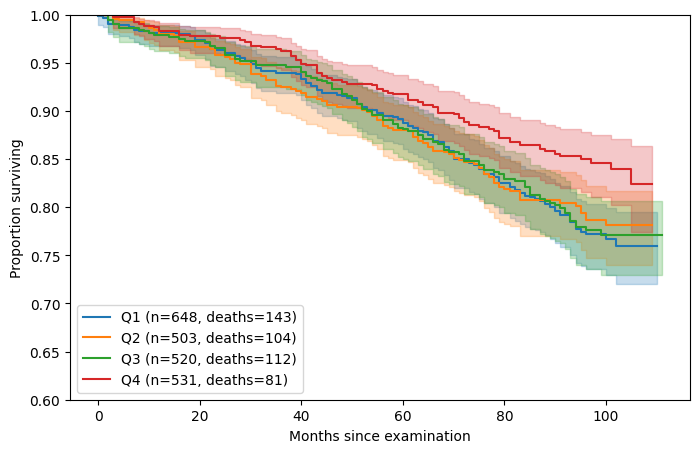

In [53]:
# Exploratory: KM by quartile WITH confidence bands. Superseded by Figure 1 (next cells).
# Retained as the evidence for dropping the bands: they overlap throughout, yet the log-rank test gives p = 0.021.

fig, ax = plt.subplots(figsize=(8, 5))

for q in ["Q1", "Q2", "Q3", "Q4"]:
    mask = surv_df["diet_q4"] == q
    kmq = KaplanMeierFitter()
    kmq.fit(durations=surv_df.loc[mask, "PERMTH_EXM"],
            event_observed=surv_df.loc[mask, "MORTSTAT"],
            label=f"{q} (n={mask.sum()}, deaths={int(surv_df.loc[mask, 'MORTSTAT'].sum())})")
    kmq.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel("Months since examination")
ax.set_ylabel("Proportion surviving")
ax.set_ylim(0.6, 1.0)
plt.show()

In [54]:
lr = multivariate_logrank_test(
    event_durations=surv_df["PERMTH_EXM"],
    groups=surv_df["diet_q4"],
    event_observed=surv_df["MORTSTAT"],
)

lr.print_summary()

print("\ntest statistic:", round(lr.test_statistic, 3))
print("degrees of freedom:", lr.degrees_of_freedom)
print("p-value:", round(lr.p_value, 4))

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           9.71 0.02      5.56


test statistic: 9.711
degrees of freedom: 3
p-value: 0.0212


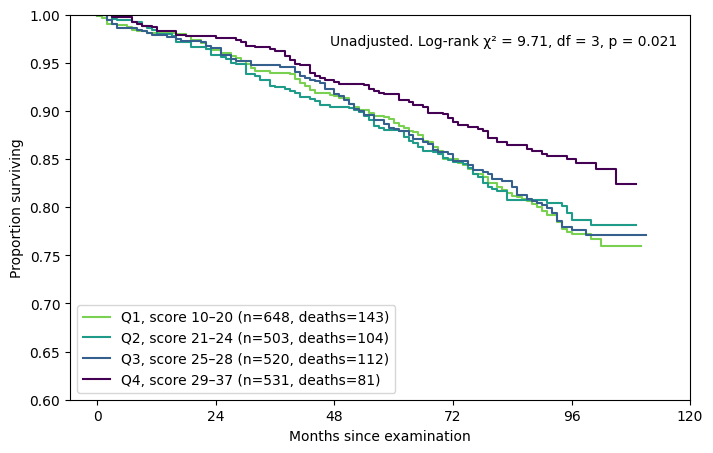

In [55]:
# Figure 1: Kaplan-Meier survival by diet-score quartile (unadjusted)
# Colours: four points on the viridis scale, lightest for Q1, darkest for Q4.
# The scale stops at 0.8 because its pale yellow end vanishes on white.
viridis_cols = plt.cm.viridis([0.8, 0.55, 0.3, 0.0])
quartile_colours = dict(zip(["Q1", "Q2", "Q3", "Q4"], viridis_cols))

fig1, ax1 = plt.subplots(figsize=(8, 5))

for q in ["Q1", "Q2", "Q3", "Q4"]:
    in_q = surv_df["diet_q4"] == q
    grp_q = surv_df.loc[in_q]
    score_lo = int(grp_q["diet_score"].min())
    score_hi = int(grp_q["diet_score"].max())
    n_deaths = int(grp_q["MORTSTAT"].sum())

    km_q = KaplanMeierFitter()
    km_q.fit(durations=grp_q["PERMTH_EXM"],
             event_observed=grp_q["MORTSTAT"],
             label=f"{q}, score {score_lo}–{score_hi} (n={len(grp_q)}, deaths={n_deaths})")
    km_q.plot_survival_function(ax=ax1, ci_show=False, color=quartile_colours[q])

ax1.set_xlabel("Months since examination")
ax1.set_ylabel("Proportion surviving")
ax1.set_ylim(0.6, 1.0)
ax1.set_xticks(range(0, 121, 24))
ax1.legend(loc="lower left")

ax1.text(0.98, 0.95,
         f"Unadjusted. Log-rank χ² = {lr.test_statistic:.2f}, "
         f"df = {lr.degrees_of_freedom}, p = {lr.p_value:.3f}",
         transform=ax1.transAxes, ha="right", va="top")

fig1.savefig("figures/fig1_km_diet_quartiles.png", dpi=300, bbox_inches="tight")

plt.show()

In [56]:
cox_cols = ["PERMTH_EXM", "MORTSTAT", "diet_score", "age_band",
            "RIAGENDR", "DMDEDUC2", "INDFMPIR", "smoker", "special_diet"]

cox_df = surv_df[cox_cols].copy()

print("before dropna:", cox_df.shape)
print("\nmissing per column:")
print(cox_df.isna().sum())

print("\ndtypes:")
print(cox_df.dtypes)

before dropna: (2202, 9)

missing per column:
PERMTH_EXM        0
MORTSTAT          0
diet_score        0
age_band          0
RIAGENDR          0
DMDEDUC2          3
INDFMPIR        198
smoker            1
special_diet      5
dtype: int64

dtypes:
PERMTH_EXM       float64
MORTSTAT         float64
diet_score         int64
age_band        category
RIAGENDR         float64
DMDEDUC2         float64
INDFMPIR         float64
smoker          category
special_diet     float64
dtype: object


In [57]:
complete = cox_df.dropna()
dropped_mask = cox_df.isna().any(axis=1)

print("complete cases:", len(complete), "of", len(cox_df),
      f"({len(complete)/len(cox_df)*100:.1f}%)")
print("dropped:", int(dropped_mask.sum()))

print("\ndeaths retained:", int(complete["MORTSTAT"].sum()), "of 440")
print("deaths dropped:", int(cox_df.loc[dropped_mask, "MORTSTAT"].sum()))

print("\ndropped vs retained:")
print("  death rate:      ",
      round(cox_df.loc[dropped_mask, "MORTSTAT"].mean(), 3), "vs",
      round(complete["MORTSTAT"].mean(), 3))
print("  mean diet_score: ",
      round(cox_df.loc[dropped_mask, "diet_score"].mean(), 2), "vs",
      round(complete["diet_score"].mean(), 2))
print("  median follow-up:",
      round(cox_df.loc[dropped_mask, "PERMTH_EXM"].median(), 1), "vs",
      round(complete["PERMTH_EXM"].median(), 1))

print("\nage band, dropped:")
print(cox_df.loc[dropped_mask, "age_band"].value_counts(normalize=True).sort_index().round(3))
print("\nage band, retained:")
print(complete["age_band"].value_counts(normalize=True).sort_index().round(3))

complete cases: 1998 of 2202 (90.7%)
dropped: 204

deaths retained: 398 of 440
deaths dropped: 42

dropped vs retained:
  death rate:       0.206 vs 0.199
  mean diet_score:  24.23 vs 23.97
  median follow-up: 92.0 vs 94.0

age band, dropped:
age_band
50-64    0.50
65-74    0.25
75+      0.25
Name: proportion, dtype: float64

age band, retained:
age_band
50-64    0.551
65-74    0.247
75+      0.202
Name: proportion, dtype: float64


In [58]:
print("age_band categories, in order:")
print(cox_df["age_band"].cat.categories.tolist())

print("\nsmoker categories, in order:")
print(cox_df["smoker"].cat.categories.tolist())

print("\nDMDEDUC2 values:", sorted(cox_df["DMDEDUC2"].dropna().unique()))
print("RIAGENDR values:", sorted(cox_df["RIAGENDR"].unique()))
print("special_diet values:", sorted(cox_df["special_diet"].dropna().unique()))

age_band categories, in order:
['50-64', '65-74', '75+']

smoker categories, in order:
['current', 'former', 'never']

DMDEDUC2 values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
RIAGENDR values: [np.float64(1.0), np.float64(2.0)]
special_diet values: [np.float64(0.0), np.float64(1.0)]


In [59]:
cox_df["smoker"] = cox_df["smoker"].cat.reorder_categories(
    ["never", "former", "current"]
)

print("smoker categories now:", cox_df["smoker"].cat.categories.tolist())
print("\ncounts unchanged:")
print(cox_df["smoker"].value_counts().sort_index())

smoker categories now: ['never', 'former', 'current']

counts unchanged:
smoker
never      1105
former      734
current     362
Name: count, dtype: int64


In [60]:
cox_ready = pd.get_dummies(
    cox_df.dropna(),
    columns=["age_band", "DMDEDUC2", "smoker"],
    drop_first=True,
)

cox_ready["RIAGENDR"] = (cox_ready["RIAGENDR"] == 2).astype(int)
cox_ready = cox_ready.rename(columns={"RIAGENDR": "female"})

print("shape:", cox_ready.shape)
print("\ncolumns:")
for c in cox_ready.columns:
    print("  ", c)
print("\ndtypes:")
print(cox_ready.dtypes.value_counts())

shape: (1998, 14)

columns:
   PERMTH_EXM
   MORTSTAT
   diet_score
   female
   INDFMPIR
   special_diet
   age_band_65-74
   age_band_75+
   DMDEDUC2_2.0
   DMDEDUC2_3.0
   DMDEDUC2_4.0
   DMDEDUC2_5.0
   smoker_former
   smoker_current

dtypes:
bool       8
float64    4
int64      2
Name: count, dtype: int64


In [61]:
cph = CoxPHFitter()
cph.fit(
    cox_ready,
    duration_col="PERMTH_EXM",
    event_col="MORTSTAT",
)

cph.print_summary(decimals=3)

<lifelines.CoxPHFitter: fitted with 1998 total observations, 1600 right-censored observations>
             duration col = 'PERMTH_EXM'
                event col = 'MORTSTAT'
      baseline estimation = breslow
   number of observations = 1998
number of events observed = 398
   partial log-likelihood = -2753.174
         time fit was run = 2026-09-21 16:37:08 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
diet_score     -0.029     0.971     0.009          -0.048          -0.011               0.953               0.989
female         -0.420     0.657     0.109          -0.633          -0.208               0.531               0.812
INDFMPIR       -0.120     0.887     0.040          -0.198          -0.043               0.821               0.958
special_diet    0.150     1.162     0.139          -0.122           0.423               0.885               1.527
age_band_65-74  1.010     2.747     0.147           0.723           1.298               2.061               3.662
age_band_75+    2.234     9.335     0.133           1.972           2.495               7.187              12.124
DMDEDUC2_2.0    0.422     1.525     0.166           0.097           0.746               1.102               2.110
DMDEDUC2_3.0    0.215     1.239     0.159          -0.097           0.526               0.907               1.693
DMDEDUC2_4.0    0.068     1.070     0.166          -0.257           0.392               0.773               1.480
DMDEDUC2_5.0   -0.401     0.670     0.204          -0.800          -0.002               0.449               0.998
smoker_former   0.121     1.128     0.115          -0.106           0.347               0.900               1.414
smoker_current  0.481     1.618     0.150           0.187           0.775               1.206               2.170

                cmp to      z       p  -log2(p)
covariate                                      
diet_score       0.000 -3.101   0.002     9.020
female           0.000 -3.874 <0.0005    13.188
INDFMPIR         0.000 -3.044   0.002     8.741
special_diet     0.000  1.082   0.279     1.840
age_band_65-74   0.000  6.890 <0.0005    37.387
age_band_75+     0.000 16.743 <0.0005   206.617
DMDEDUC2_2.0     0.000  2.546   0.011     6.522
DMDEDUC2_3.0     0.000  1.348   0.178     2.492
DMDEDUC2_4.0     0.000  0.408   0.684     0.549
DMDEDUC2_5.0     0.000 -1.969   0.049     4.352
smoker_former    0.000  1.045   0.296     1.757
smoker_current   0.000  3.210   0.001     9.559
---
Concordance = 0.780
Partial AIC = 5530.349
log-likelihood ratio test = 413.726 on 12 df
-log2(p) of ll-ratio test = 266.849

In [62]:
sd = cox_ready["diet_score"].std()
b = cph.params_["diet_score"]
lo, hi = cph.confidence_intervals_.loc["diet_score"]

print("diet_score SD in model sample:", round(sd, 3))
print("\nper 1 point: HR", round(np.exp(b), 3),
      "(", round(np.exp(lo), 3), "-", round(np.exp(hi), 3), ")")
print("per 1 SD:    HR", round(np.exp(b * sd), 3),
      "(", round(np.exp(lo * sd), 3), "-", round(np.exp(hi * sd), 3), ")")

diet_score SD in model sample: 5.603

per 1 point: HR 0.971 ( 0.953 - 0.989 )
per 1 SD:    HR 0.848 ( 0.764 - 0.941 )


In [63]:
results = cph.check_assumptions(cox_ready, p_value_threshold=0.05, show_plots=False)

Proportional hazard assumption looks okay.


In [64]:
dens_cols = ["fibre_dens", "potassium_dens", "magnesium_dens", "calcium_dens",
             "vitamin_c_dens", "sodium_dens", "sat_fat_dens", "sugar_dens"]

l4_raw_cols = dens_cols + ["DR1TKCAL", "special_diet", "age_band",
                           "RIAGENDR", "DMDEDUC2", "INDFMPIR", "smoker"]

l4_df = model_df[l4_raw_cols + ["mets"]].copy()

print("features requested:", len(l4_raw_cols))
print("frame shape:", l4_df.shape)
print("\nmissing per column:")
print(l4_df.isna().sum())

features requested: 15
frame shape: (1015, 16)

missing per column:
fibre_dens          0
potassium_dens      0
magnesium_dens      0
calcium_dens        0
vitamin_c_dens      0
sodium_dens         0
sat_fat_dens        0
sugar_dens          0
DR1TKCAL            0
special_diet        4
age_band            0
RIAGENDR            0
DMDEDUC2            1
INDFMPIR          104
smoker              1
mets                0
dtype: int64


In [65]:
l4_fixed = l4_df.dropna().copy()
l4_fixed["smoker"] = pd.Categorical(
    l4_fixed["smoker"], categories=["never", "former", "current"], ordered=False)

l4_ready = pd.get_dummies(l4_fixed, columns=["age_band", "smoker", "DMDEDUC2"],
                          drop_first=True)

print("after dropna:  ", l4_fixed.shape)
print("after encoding:", l4_ready.shape)

print("\nsmoker columns:", [c for c in l4_ready.columns if "smoker" in c])
print("age columns:   ", [c for c in l4_ready.columns if "age_band" in c])
print("education columns:", [c for c in l4_ready.columns if "DMDEDUC2" in c])

print("\nany remaining missing:", l4_ready.isna().sum().sum())

after dropna:   (906, 16)
after encoding: (906, 21)

smoker columns: ['smoker_former', 'smoker_current']
age columns:    ['age_band_65-74', 'age_band_75+']
education columns: ['DMDEDUC2_2.0', 'DMDEDUC2_3.0', 'DMDEDUC2_4.0', 'DMDEDUC2_5.0']

any remaining missing: 0


In [66]:
y = l4_ready["mets"]
X = l4_ready.drop(columns=["mets"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("mets prevalence — train: {:.3f}  test: {:.3f}".format(
    y_train.mean(), y_test.mean()))
print("\nleakage check — 'mets' in feature columns:",
      [c for c in X.columns if "mets" in c.lower()])

X_train: (679, 20)  X_test: (227, 20)
mets prevalence — train: 0.638  test: 0.639

leakage check — 'mets' in feature columns: []


In [67]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("train scaled — mean of first 5 cols:", X_train_s.mean(axis=0).round(3)[:5])
print("train scaled — sd of first 5 cols:  ", X_train_s.std(axis=0).round(3)[:5])
print("test scaled  — mean of first 5 cols:", X_test_s.mean(axis=0).round(3)[:5])

logit = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
logit.fit(X_train_s, y_train)

print("\nfeatures seen by the model:", logit.n_features_in_)
print("iterations used:", logit.n_iter_, "(cap 1000)")

train scaled — mean of first 5 cols: [ 0. -0. -0.  0.  0.]
train scaled — sd of first 5 cols:   [1. 1. 1. 1. 1.]
test scaled  — mean of first 5 cols: [-0.044 -0.09   0.012  0.053 -0.07 ]

features seen by the model: 20
iterations used: [12] (cap 1000)


In [68]:
pred_label = logit.predict(X_test_s)
pred_prob = logit.predict_proba(X_test_s)

print("classes_:", logit.classes_)
print("\npredict()       shape:", pred_label.shape, " first 10:", pred_label[:10])
print("predict_proba() shape:", pred_prob.shape)
print("\nfirst 5 rows of predict_proba:")
print(pred_prob[:5].round(3))
print("\nrow sums (first 5):", pred_prob[:5].sum(axis=1).round(3))

print("\nshare predicted positive:", round(pred_label.mean(), 3),
      " actual share positive:", round(y_test.mean(), 3))

classes_: [0 1]

predict()       shape: (227,)  first 10: [1 1 1 1 1 1 1 1 1 1]
predict_proba() shape: (227, 2)

first 5 rows of predict_proba:
[[0.409 0.591]
 [0.082 0.918]
 [0.481 0.519]
 [0.236 0.764]
 [0.395 0.605]]

row sums (first 5): [1. 1. 1. 1. 1.]

share predicted positive: 0.811  actual share positive: 0.639


In [69]:
p_test = pred_prob[:, 1]
p_train = logit.predict_proba(X_train_s)[:, 1]

auc_train = roc_auc_score(y_train, p_train)
auc_test = roc_auc_score(y_test, p_test)

print("logistic AUC — train: {:.3f}   test: {:.3f}".format(auc_train, auc_test))
print("gap (train − test):   {:.3f}".format(auc_train - auc_test))

print("\nchecks")
print("AUC from the class-0 column (should be 1 − test AUC):",
      round(roc_auc_score(y_test, pred_prob[:, 0]), 3))
print("AUC of a constant prediction (should be 0.500):",
      round(roc_auc_score(y_test, [0.5] * len(y_test)), 3))

logistic AUC — train: 0.662   test: 0.663
gap (train − test):   -0.001

checks
AUC from the class-0 column (should be 1 − test AUC): 0.337
AUC of a constant prediction (should be 0.500): 0.5


In [70]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_p_train = gb.predict_proba(X_train)[:, 1]
gb_p_test = gb.predict_proba(X_test)[:, 1]

gb_auc_train = roc_auc_score(y_train, gb_p_train)
gb_auc_test = roc_auc_score(y_test, gb_p_test)

print("classes_:", gb.classes_)
print("features seen:", gb.n_features_in_, " trees fitted:", gb.n_estimators_)

print("\n            train    test     gap")
print("logistic    {:.3f}   {:.3f}   {:+.3f}".format(
    auc_train, auc_test, auc_train - auc_test))
print("boosting    {:.3f}   {:.3f}   {:+.3f}".format(
    gb_auc_train, gb_auc_test, gb_auc_train - gb_auc_test))
print("\ndifference in test AUC (boosting − logistic): {:+.3f}".format(
    gb_auc_test - auc_test))

classes_: [0 1]
features seen: 20  trees fitted: 100

            train    test     gap
logistic    0.662   0.663   -0.001
boosting    0.990   0.618   +0.372

difference in test AUC (boosting − logistic): -0.045


In [71]:
# Figure 3 data: number of MetS criteria met, fasting subsample, both definitions
count_table = pd.DataFrame({
    "primary": df.loc[fasting, "mets_count"].value_counts().sort_index(),
    "meas_only": df.loc[fasting, "mets_count_meas"].value_counts().sort_index(),
})
count_table = count_table.reindex(range(6), fill_value=0)

count_pct = count_table / count_table.sum() * 100

print(count_table)
print("\ncolumn totals:")
print(count_table.sum())
print("\npercentages:")
print(count_pct.round(1))

   primary  meas_only
0       59         69
1      122        166
2      187        269
3      223        301
4      214        140
5      210         70

column totals:
primary      1015
meas_only    1015
dtype: int64

percentages:
   primary  meas_only
0      5.8        6.8
1     12.0       16.4
2     18.4       26.5
3     22.0       29.7
4     21.1       13.8
5     20.7        6.9


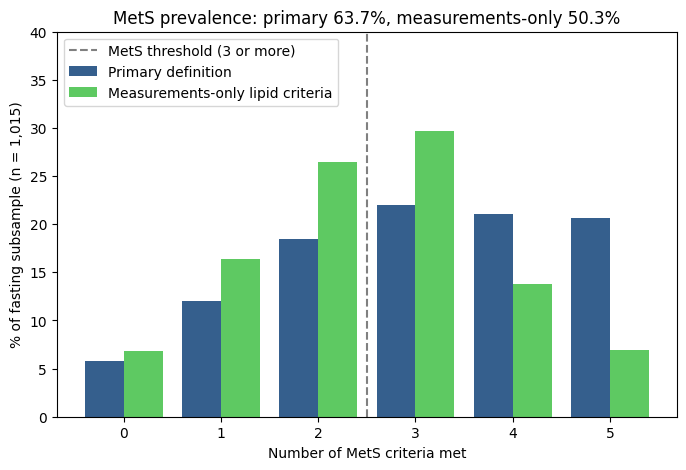

In [72]:
# Figure 3: distribution of MetS criteria met, primary vs measurements-only definition
def_colours = plt.cm.viridis([0.3, 0.75])
bar_x = np.arange(6)
bar_w = 0.4
n_fast = int(count_table["primary"].sum())

prev_primary = count_table.loc[3:5, "primary"].sum() / n_fast * 100
prev_meas = count_table.loc[3:5, "meas_only"].sum() / n_fast * 100

fig3, ax3 = plt.subplots(figsize=(8, 5))

ax3.bar(bar_x - bar_w / 2, count_pct["primary"], bar_w,
        label="Primary definition", color=def_colours[0])
ax3.bar(bar_x + bar_w / 2, count_pct["meas_only"], bar_w,
        label="Measurements-only lipid criteria", color=def_colours[1])

ax3.axvline(2.5, color="grey", linestyle="--", label="MetS threshold (3 or more)")

ax3.set_xticks(bar_x)
ax3.set_xlabel("Number of MetS criteria met")
ax3.set_ylabel(f"% of fasting subsample (n = {n_fast:,})")
ax3.set_ylim(0, 40)
ax3.legend(loc="upper left")

ax3.set_title(f"MetS prevalence: primary {prev_primary:.1f}%, "
              f"measurements-only {prev_meas:.1f}%")

fig3.savefig("figures/fig3_mets_criteria_count.png", dpi=300, bbox_inches="tight")

plt.show()

In [73]:
# Figure 2 data: diet_score estimates per 1-point increase, read from the fitted models
# Coefficients and CI bounds are stored on the log scale; np.exp converts them to ratios.
est_l2 = pd.DataFrame({
    "estimate": [m1.params["diet_score"], m2.params["diet_score"]],
    "ci_low":   [m1.conf_int().loc["diet_score", 0], m2.conf_int().loc["diet_score", 0]],
    "ci_high":  [m1.conf_int().loc["diet_score", 1], m2.conf_int().loc["diet_score", 1]],
}, index=["Primary definition", "Measurements-only lipids"])
est_l2 = np.exp(est_l2)
est_l2["p"] = [m1.pvalues["diet_score"], m2.pvalues["diet_score"]]

est_cox = pd.DataFrame({
    "estimate": [cph.params_["diet_score"]],
    "ci_low":   [cph.confidence_intervals_.loc["diet_score", "95% lower-bound"]],
    "ci_high":  [cph.confidence_intervals_.loc["diet_score", "95% upper-bound"]],
}, index=["All-cause mortality"])
est_cox = np.exp(est_cox)
est_cox["p"] = [cph.summary.loc["diet_score", "p"]]

print("Layer 2 — odds ratio per point of diet score:")
print(est_l2.round(3))
print("\nLayer 3 — hazard ratio per point of diet score:")
print(est_cox.round(3))

Layer 2 — odds ratio per point of diet score:
                          estimate  ci_low  ci_high     p
Primary definition           0.976   0.951    1.003  0.08
Measurements-only lipids     0.978   0.954    1.003  0.09

Layer 3 — hazard ratio per point of diet score:
                     estimate  ci_low  ci_high      p
All-cause mortality     0.971   0.953    0.989  0.002


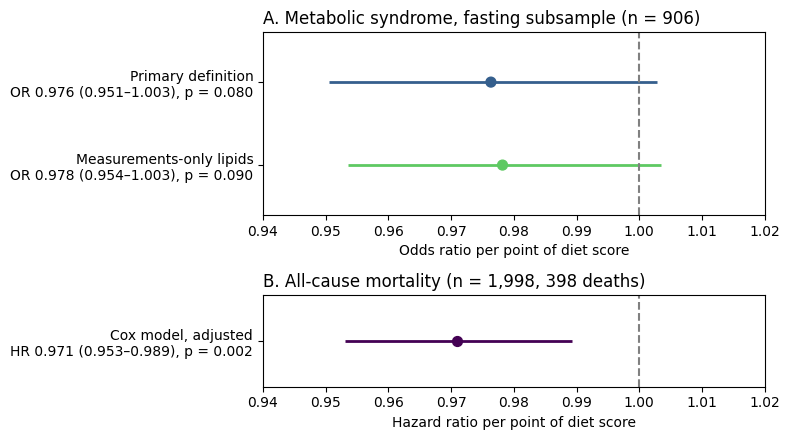

In [74]:
# Figure 2: diet_score estimates per point. A: Layer 2 odds ratios. B: Cox hazard ratio.
# Different measures, so separate panels and axis labels; same x-range so widths are comparable honestly.
fp_cols = plt.cm.viridis([0.3, 0.75, 0.0])
n_l2 = int(m1.nobs)
n_cox = len(cox_ready)
d_cox = int(cox_ready["MORTSTAT"].sum())

fig2, (ax_or, ax_hr) = plt.subplots(2, 1, figsize=(8, 4.5),
                                    gridspec_kw={"height_ratios": [2, 1]})

# Panel A: Layer 2, two definitions of MetS
or_y = [1, 0]
ax_or.hlines(y=or_y, xmin=est_l2["ci_low"], xmax=est_l2["ci_high"],
             colors=fp_cols[:2], linewidth=2)
ax_or.scatter(est_l2["estimate"], or_y, color=fp_cols[:2], s=50, zorder=3)
or_labels = [f"{row_name}\nOR {row.estimate:.3f} ({row.ci_low:.3f}–{row.ci_high:.3f}), p = {row.p:.3f}"
             for row_name, row in est_l2.iterrows()]
ax_or.set_yticks(or_y)
ax_or.set_yticklabels(or_labels)
ax_or.set_ylim(-0.6, 1.6)
ax_or.axvline(1, color="grey", linestyle="--")
ax_or.set_xlim(0.94, 1.02)
ax_or.set_xlabel("Odds ratio per point of diet score")
ax_or.set_title(f"A. Metabolic syndrome, fasting subsample (n = {n_l2:,})", loc="left")

# Panel B: Layer 3, Cox model
hr_y = [0]
ax_hr.hlines(y=hr_y, xmin=est_cox["ci_low"], xmax=est_cox["ci_high"],
             colors=fp_cols[2:], linewidth=2)
ax_hr.scatter(est_cox["estimate"], hr_y, color=fp_cols[2:], s=50, zorder=3)
hr_labels = [f"Cox model, adjusted\nHR {row.estimate:.3f} ({row.ci_low:.3f}–{row.ci_high:.3f}), p = {row.p:.3f}"
             for row_name, row in est_cox.iterrows()]
ax_hr.set_yticks(hr_y)
ax_hr.set_yticklabels(hr_labels)
ax_hr.set_ylim(-0.8, 0.8)
ax_hr.axvline(1, color="grey", linestyle="--")
ax_hr.set_xlim(0.94, 1.02)
ax_hr.set_xlabel("Hazard ratio per point of diet score")
ax_hr.set_title(f"B. All-cause mortality (n = {n_cox:,}, {d_cox} deaths)", loc="left")

fig2.tight_layout()
fig2.savefig("figures/fig2_diet_score_estimates.png", dpi=300, bbox_inches="tight")

plt.show()